Mount Project to Folder

In [1]:
# Install the Rapid Deep Neural Networks library
!pip install radnn -q
!pip list | grep "radnn"

from radnn.system.hosts import ColabHost

# Mount to the project folder that is under the lesson folder
ColabHost().detect_workspace(["Final_Project_Workspace", "MSDS680"]).change_to_project_dir("George Aslanidis 20220440 - Semester Project")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.6 MB/s eta 0:00:00
radnn                                 0.0.9
Mounted at /content/gdrive
Current directory is:  /content/gdrive/My Drive/Colab Notebooks/Final_Project_Workspace/George Aslanidis 20220440 - Semester Project


Host: (colab)-172.28.0.12

# **Part I: Install and Import Dependencies**


In [2]:
import numpy as np
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from tqdm import tqdm  # For progress bar

# **Part II: Load Data & Convert Audio to Spectrograms**


**1. Load & Process Data from Kegglehub**

- Load Files (location: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification)


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


**2. Convert Audio to Spectrogram Function**


In [ ]:
# Used for all other experiments from 12 and earlier
def audio_to_spectrogram(file_path):
    y, sr = librosa.load(file_path, duration=30)  # Load 30s audio
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)  # Convert to decibels

    # Resize to fixed shape (CNN expects fixed input size)
    return np.resize(mel_spec_db, (128, 128))  # Convert to 128x128 "image"

In [ ]:
genres = ['blues', 'classical', 'jazz', 'rock', 'country', 'disco', 'hiphop', 'metal', 'pop', 'reggae']

# Corrected Dataset Path
dataset_path = "/root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/"

# Prepare lists to store spectrogram data and labels
data, labels = [], []

# Fixed Genre Loop
for genre in tqdm(genres, desc="Processing Genres"):
    genre_path = os.path.join(dataset_path, genre)

    if os.path.isdir(genre_path):
        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)
            if file_path.endswith('.wav') or file_path.endswith('.mp3'):
                try:
                    spectrogram = audio_to_spectrogram(file_path)
                    data.append(spectrogram)
                    labels.append(genres.index(genre))  # Convert genre to numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")
    else:
        print(f"Folder {genre_path} not found!")  # Will now correctly show missing folders

# Convert lists to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Reshape data for CNN (Add channel dimension)
data = data.reshape(data.shape[0], 128, 128, 1)  # (samples, height, width, channels)

print(f"Data shape: {data.shape}, Labels shape: {labels.shape}")


**3. Split into Train/Test Sets**

In [ ]:
# Test Size = Test Set = 20%

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(genres))
y_test = to_categorical(y_test, num_classes=len(genres))


# **Part III: Training the Baseline CNN Model**

**1. Define of a Simple CNN Model**

In [ ]:
# CNN MODEL

model = tf.keras.Sequential([
    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Flatten & Fully Connected Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output Layer for Classification
    tf.keras.layers.Dense(len(genres), activation='softmax')
])

model.summary()

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

**2. Train the Model**

In [ ]:
# Train the model and get the history object
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1215 - loss: 11.3954 - val_accuracy: 0.1300 - val_loss: 2.2569
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1953 - loss: 2.2185 - val_accuracy: 0.1550 - val_loss: 2.2058
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2143 - loss: 2.2475 - val_accuracy: 0.1400 - val_loss: 2.2288
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.1709 - loss: 2.2755 - val_accuracy: 0.1700 - val_loss: 2.2000
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.2407 - loss: 2.1591 - val_accuracy: 0.0900 - val_loss: 2.2849
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1668 - loss: 2.2638 - val_accuracy: 0.1850 - val_loss: 2.1398
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2760 - loss: 2.0737 - val_accuracy: 0.1900 - val_loss: 2.1373
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.3032 - loss: 2.0086 - val_accuracy: 0.2150 - val_loss

**3. Evaluate the Model**

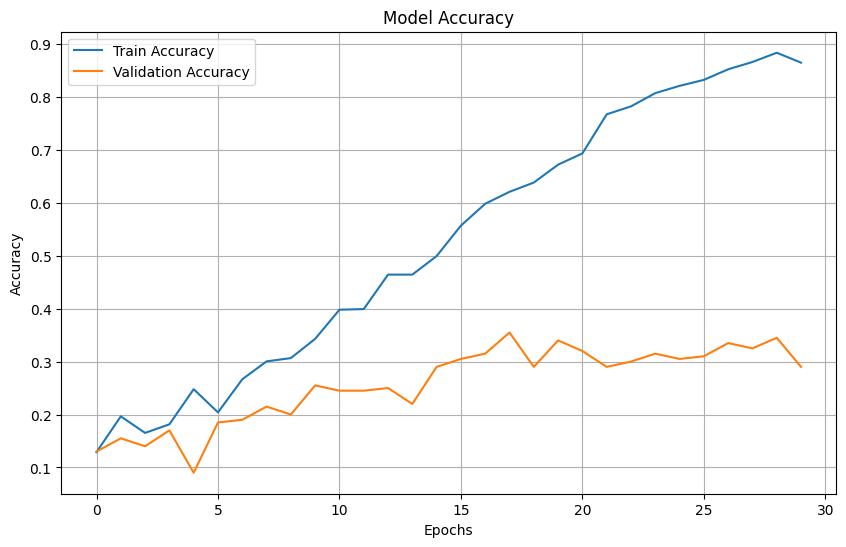

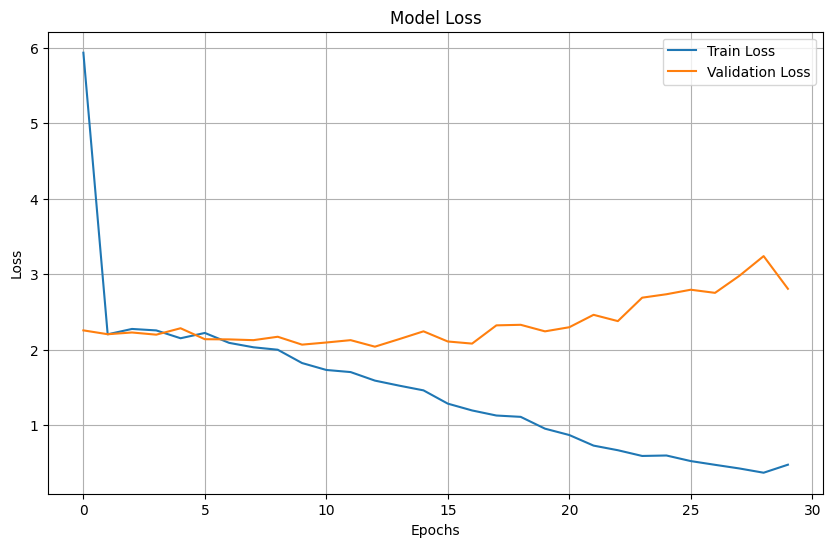

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step


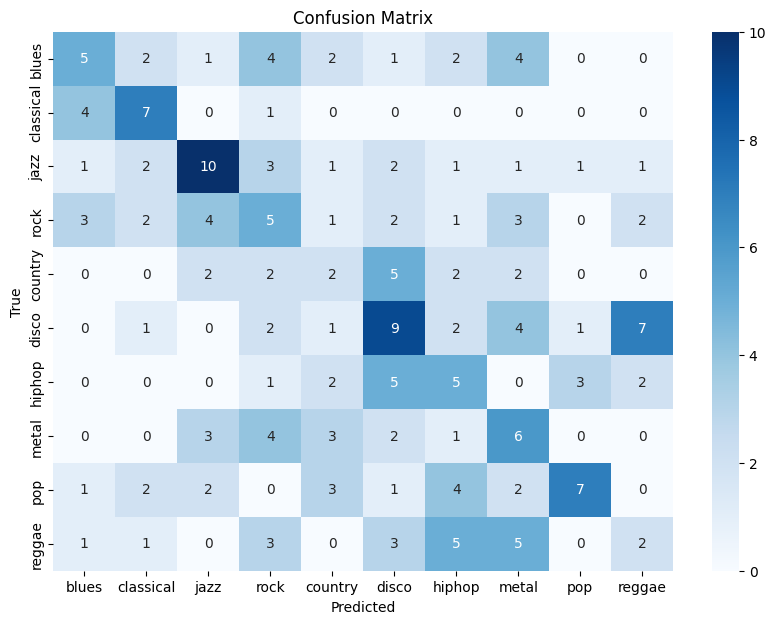

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.3072 - loss: 2.7978
Test Accuracy: 0.2900


In [ ]:

# -------------------------ACCURACY AND LOSS PLOTS------------------------------

# Plot Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig("LearningCurve_Accuracy.png")  # Save the accuracy plot
plt.show()

# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig("LearningCurve_Loss.png")  # Save the loss plot
plt.show()

# --------------------------CONFUSION MATRIX----------------------------

# Make predictions on the test set
predictions = model.predict(X_test)

# Get the predicted class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert y_test to class labels (if it's one-hot encoded)
true_labels = np.argmax(y_test, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# -------------------------EVALUATION RESULTS---------------------------
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# **Part IV: Experiments for Improved Model**

**1. Experiment with Hyperparameters & Different Optimizers**

Try:

  - Changing the number of layers/neurons
  - Using different optimizers (Adam, SGD, RMSprop)
  - Adding Batch Normalization, Dropout, momentum, and Learning Rate Scheduling
  - Changing Test - Validation Sets Proportions
  - Addition of Augmentation Functions
  

In [3]:
from tqdm import tqdm  # Progress bar for processing

# Define Constants
IMG_SIZE = 128  # Spectrogram size
SAMPLE_RATE = 22050  # Standard audio sample rate
DURATION = 30  # 30 seconds per audio clip

# Convert Audio to Spectrogram
def audio_to_spectrogram(y, sr, img_size=IMG_SIZE):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=img_size, n_fft=4096, hop_length=1024)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db = librosa.util.fix_length(mel_spec_db, size=img_size, axis=1)  # Fix time axis
    mel_spec_db = np.resize(mel_spec_db, (img_size, img_size))
    return mel_spec_db

# Time Stretching (Corrected)
def time_stretch(y, rate=1.0):
    return librosa.effects.time_stretch(y=y, rate=rate)

# Pitch Shifting (Corrected)
def pitch_shift(y, sr=22050, n_steps=2):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

# Add Noise
def add_noise(y, noise_factor=0.005):
    noise = noise_factor * np.random.randn(len(y))
    return y + noise

# Function to Extract Features with Augmentation
def extract_features_with_augmentation(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)  # Load 30s of the audio file
    except:
        print(f'Error loading {file_path}')
        return []

    features = []
    features.append(audio_to_spectrogram(y, sr))  # Original Spectrogram

    # Augmented Features
    features.append(audio_to_spectrogram(time_stretch(y, rate=0.8), sr))  # Slower
    features.append(audio_to_spectrogram(time_stretch(y, rate=1.2), sr))  # Faster
    features.append(audio_to_spectrogram(pitch_shift(y, sr, n_steps=2), sr))  # Pitch Up
    features.append(audio_to_spectrogram(pitch_shift(y, sr, n_steps=-2), sr))  # Pitch Down
    features.append(audio_to_spectrogram(add_noise(y, noise_factor=0.005), sr))  # Noise Added

    return features  # Returns a list of spectrograms

In [8]:
# Define genres
with tf.device('/GPU:0'):
  genres = ['blues', 'classical', 'jazz', 'rock', 'country', 'disco', 'hiphop', 'metal', 'pop', 'reggae']

  dataset_path = "/root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/"

  data, labels = [], []

  # Process each genre folder
  for genre in tqdm(genres, desc="Processing Genres"):
      genre_path = os.path.join(dataset_path, genre)

      if os.path.isdir(genre_path):  # Ensure the folder exists
          for file in os.listdir(genre_path):
              file_path = os.path.join(genre_path, file)
              if file_path.endswith('.wav') or file_path.endswith('.mp3'):
                  try:
                      spectrograms = extract_features_with_augmentation(file_path)  # Extract + Augment
                      for spectrogram in spectrograms:
                          data.append(spectrogram)
                          labels.append(genres.index(genre))  # Convert genre to numeric label
                  except Exception as e:
                      print(f"Error processing {file_path}: {e}")
      else:
          print(f"Folder {genre_path} not found!")

  # Convert lists to NumPy arrays
  data = np.array(data)
  labels = np.array(labels)

  # Reshape data for CNN (Add channel dimension)
  data = data.reshape(data.shape[0], IMG_SIZE, IMG_SIZE, 1)  # (samples, height, width, channels)

  print(f"Data shape: {data.shape}, Labels shape: {labels.shape}")

Processing Genres: 100%|██████████| 10/10 [00:00<00:00, 20049.25it/s]

Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/blues not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/classical not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/jazz not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/rock not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/country not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/disco not found!
Folder /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/hipho

In [ ]:
# Split dataset ensuring equal representation per class
# 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, stratify=labels, random_state=42
)

y_train = to_categorical(y_train, num_classes=len(genres))
y_test = to_categorical(y_test, num_classes=len(genres))

In [ ]:
# Learning Rate Scheduler function
def scheduler(epoch, lr):
    if epoch < 13:
        return 0.0001   # Initial learning rate, change after 20 epochs
    elif epoch < 20:
        return 0.00005
    else:
        return 0.00001

Epoch 1/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.2753 - loss: 6.8167 - val_accuracy: 0.2193 - val_loss: 6.4787 - learning_rate: 1.0000e-04
Epoch 2/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5122 - loss: 5.7364 - val_accuracy: 0.4712 - val_loss: 5.6115 - learning_rate: 1.0000e-04
Epoch 3/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5989 - loss: 5.1320 - val_accuracy: 0.5863 - val_loss: 4.9413 - learning_rate: 1.0000e-04
Epoch 4/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6516 - loss: 4.6379 - val_accuracy: 0.6197 - val_loss: 4.4916 - learning_rate: 1.0000e-04
Epoch 5/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7056 - loss: 4.1997 - val_accuracy: 0.7048 - val_loss: 4.0203 - learning_rate: 1.0000e-04
Epoch 6/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7501 - loss: 3.8459 - val_accuracy: 0.7323 - val_loss: 3.7513 - learning_rate: 1.0000e-04
Epoch 7/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/st

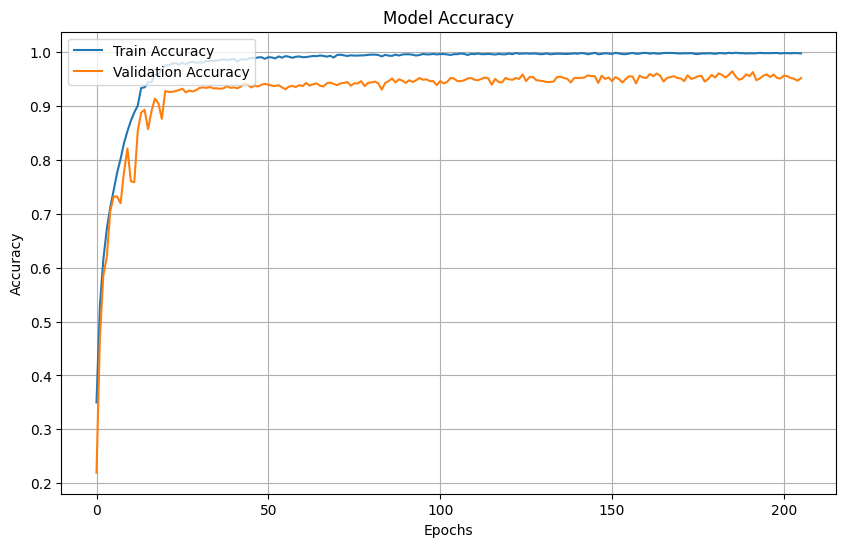

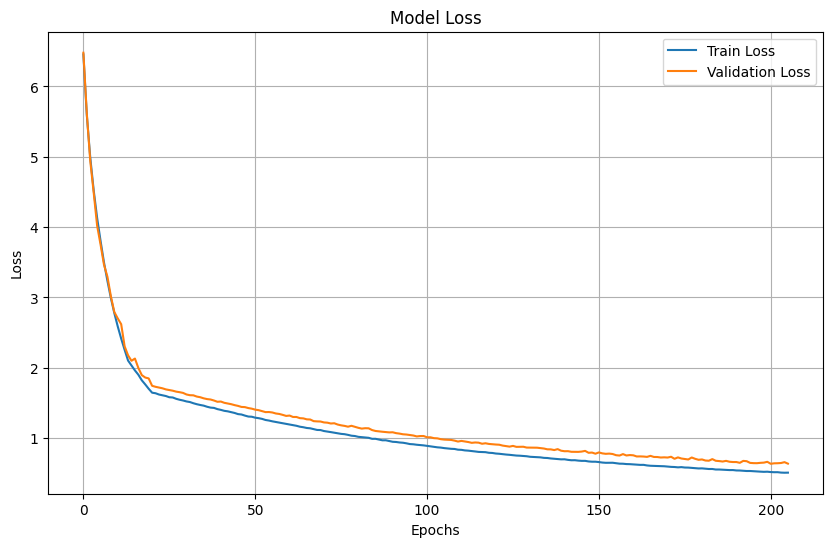

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


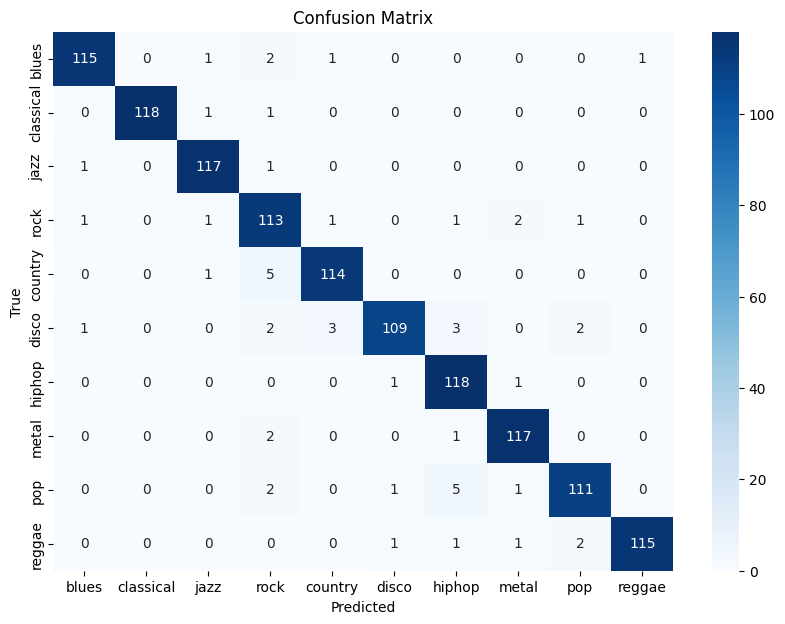

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9598 - loss: 0.6256
Test Accuracy: 0.9566


In [ ]:
# Improved CNN Model with Stem and Increased Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2

# Define the Model
modelImproved = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(128, 128, 1)),

    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(96, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Fourth Convolutional Block
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Global Average Pooling
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully Connected Layer
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.02)),
    tf.keras.layers.Dropout(0.3),

    # Output Layer (Softmax for Multiclass Classification)
    tf.keras.layers.Dense(len(genres), activation='softmax')
])

# **Optimized Adam Optimizer**
optimizer = Adam(learning_rate=0.0001)

# **Compile the Model**
modelImproved.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# **Early Stopping (Patience = 5)**
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# **Train the Model**
history = modelImproved.fit(X_train, y_train, epochs=500, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stopping, LearningRateScheduler(scheduler)]) #, LearningRateScheduler(scheduler)



# ------------------------------ PLOTS ----------------------------------

# Plot Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig("LearningCurve_Accuracy.png")  # Save the accuracy plot
plt.show()

# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig("LearningCurve_Loss.png")  # Save the loss plot
plt.show()


# --------------------------CONFUSION MATRIX----------------------------

# Make predictions on the test set
predictions = modelImproved.predict(X_test)

# Get the predicted class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert y_test to class labels (if it's one-hot encoded)
true_labels = np.argmax(y_test, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# -------------------------EVALUATION RESULTS---------------------------
# Evaluate the model
test_loss, test_acc = modelImproved.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
# Save the model
modelImproved.save('genre_classifier_model.keras')